In [8]:
zip_path="C:/Users/User/Downloads/CMP_facade_DB_base.zip"

In [9]:
from pathlib import Path
import argparse
import os
import math
import random
import sys
import glob
import time
import datetime
import itertools
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import zipfile
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.utils import save_image, make_grid

In [10]:

zip_path = "C:/Users/User/Downloads/CMP_facade_DB_base.zip"
extract_dir = "C:/dataset"
os.makedirs(extract_dir, exist_ok=True)

# Распаковка
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

In [11]:
facades_dir = os.path.join(extract_dir, "facades")
schemes_dir = os.path.join(extract_dir, "schemes")
os.makedirs(facades_dir, exist_ok=True)
os.makedirs(schemes_dir, exist_ok=True)

In [12]:
base_dir = os.path.join(extract_dir, "base")  # Папка с распакованными файлами
files = os.listdir(base_dir)

for file in files:
    src_path = os.path.join(base_dir, file)

    if file.endswith('.jpg'):
        
        new_name = f"фасад{file.split('_')[-1].split('.')[0]}.jpg"  #  cmp_b0222.jpg → фасад0222.jpg
        dst_path = os.path.join(facades_dir, new_name)
        os.rename(src_path, dst_path)

    elif file.endswith('.png'):
        
        new_name = f"схема{file.split('_')[-1].split('.')[0]}.png"  # cmp_b0222.png → схема0222.png
        dst_path = os.path.join(schemes_dir, new_name)
        os.rename(src_path, dst_path)

In [13]:

facades_files = sorted(os.listdir(facades_dir))
schemes_files = sorted(os.listdir(schemes_dir))

# проверяем, что для каждого фасада есть схема
for facade, scheme in zip(facades_files, schemes_files):
    facade_num = facade.replace('фасад', '').replace('.jpg', '')
    scheme_num = scheme.replace('схема', '').replace('.png', '')

    if facade_num != scheme_num:
        print(f"Несоответствие: {facade} ↔ {scheme}")
    else:
        print(f"Пара найдена: {facade} ↔ {scheme}")

Пара найдена: фасадb0001.jpg ↔ схемаb0001.png
Пара найдена: фасадb0002.jpg ↔ схемаb0002.png
Пара найдена: фасадb0003.jpg ↔ схемаb0003.png
Пара найдена: фасадb0004.jpg ↔ схемаb0004.png
Пара найдена: фасадb0005.jpg ↔ схемаb0005.png
Пара найдена: фасадb0006.jpg ↔ схемаb0006.png
Пара найдена: фасадb0007.jpg ↔ схемаb0007.png
Пара найдена: фасадb0008.jpg ↔ схемаb0008.png
Пара найдена: фасадb0009.jpg ↔ схемаb0009.png
Пара найдена: фасадb0010.jpg ↔ схемаb0010.png
Пара найдена: фасадb0011.jpg ↔ схемаb0011.png
Пара найдена: фасадb0012.jpg ↔ схемаb0012.png
Пара найдена: фасадb0013.jpg ↔ схемаb0013.png
Пара найдена: фасадb0014.jpg ↔ схемаb0014.png
Пара найдена: фасадb0015.jpg ↔ схемаb0015.png
Пара найдена: фасадb0016.jpg ↔ схемаb0016.png
Пара найдена: фасадb0017.jpg ↔ схемаb0017.png
Пара найдена: фасадb0018.jpg ↔ схемаb0018.png
Пара найдена: фасадb0019.jpg ↔ схемаb0019.png
Пара найдена: фасадb0020.jpg ↔ схемаb0020.png
Пара найдена: фасадb0021.jpg ↔ схемаb0021.png
Пара найдена: фасадb0022.jpg ↔ схе

In [14]:
class ReplayBuffer:
    def __init__(self, max_size=50):
        assert max_size > 0, "Пусто"
        self.max_size = max_size
        self.data = []

    def push_and_pop(self, data):
        to_return = []
        for element in data.data:
            element = torch.unsqueeze(element, 0)
            if len(self.data) < self.max_size:
                self.data.append(element)
                to_return.append(element)
            else:
                if random.uniform(0, 1) > 0.5:
                    i = random.randint(0, self.max_size - 1)
                    to_return.append(self.data[i].clone())
                    self.data[i] = element
                else:
                    to_return.append(element)
        return Variable(torch.cat(to_return))

class LambdaLR:
    def __init__(self, n_epochs, offset, decay_start_epoch):
        assert (n_epochs - decay_start_epoch) > 0, "Затухание"
        self.n_epochs = n_epochs
        self.offset = offset
        self.decay_start_epoch = decay_start_epoch

    def step(self, epoch):
        return 1.0 - max(0, epoch + self.offset - self.decay_start_epoch) / (self.n_epochs - self.decay_start_epoch)

In [15]:
class PairedFacadesDataset(Dataset):
    def __init__(self, root_dir, transform=None, mode="train", unaligned=False):

        self.transform = transform
        self.mode = mode
        self.unaligned = unaligned

        # Получаем списки файлов
        facades_dir = os.path.join(root_dir, 'facades')
        schemes_dir = os.path.join(root_dir, 'schemes')

        self.facades = sorted([os.path.join(facades_dir, f) for f in os.listdir(facades_dir)
                             if f.endswith('.jpg')])
        self.schemes = sorted([os.path.join(schemes_dir, f) for f in os.listdir(schemes_dir)
                             if f.endswith('.png')])

        # Для теста берем подмножество
        if mode == "test":
            self.facades = self.facades[:min(10, len(self.facades))]
            self.schemes = self.schemes[:min(10, len(self.schemes))]

        # Проверяем соответствие пар
        if not unaligned:
            self._validate_pairs()

    def _validate_pairs(self):
        """Проверяет, что файлы имеют соответствующие пары"""
        for f, s in zip(self.facades, self.schemes):
            f_num = os.path.basename(f).replace('фасад', '').replace('.jpg', '')
            s_num = os.path.basename(s).replace('схема', '').replace('.png', '')
            if f_num != s_num:
                raise ValueError(f"Несоответствие пар: {f} ↔ {s}")

    def __len__(self):
        return max(len(self.facades), len(self.schemes)) if self.unaligned else min(len(self.facades), len(self.schemes))

    def __getitem__(self, idx):
        
        facade = Image.open(self.facades[idx])
        if facade.mode != 'RGB':
            facade = facade.convert('RGB')

        
        scheme = Image.open(self.schemes[idx])
        if scheme.mode != 'RGB':
            scheme = scheme.convert('RGB')

      
        if self.transform:
            facade = self.transform(facade)
            scheme = self.transform(scheme)

        return {'facade': facade, 'scheme': scheme}

In [16]:
def weights_init_normal(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        torch.nn.init.normal_(m.weight.data, 0.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            torch.nn.init.constant_(m.bias.data, 0.0)
    elif classname.find("BatchNorm2d") != -1:
        torch.nn.init.normal_(m.weight.data, 1.0, 0.02)
        torch.nn.init.constant_(m.bias.data, 0.0)

class ResidualBlock(nn.Module):
    def __init__(self, in_features):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_features, in_features, 3),
            nn.InstanceNorm2d(in_features),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_features, in_features, 3),
            nn.InstanceNorm2d(in_features),
        )

    def forward(self, x):
        return x + self.block(x)

class GeneratorResNet(nn.Module):
    def __init__(self, input_shape, num_residual_blocks):
        super(GeneratorResNet, self).__init__()
        channels = input_shape[0]
        out_features = 64
        model = [
            nn.ReflectionPad2d(channels),
            nn.Conv2d(channels, out_features, 7),
            nn.InstanceNorm2d(out_features),
            nn.ReLU(inplace=True),
        ]
        in_features = out_features
        for _ in range(2):
            out_features *= 2
            model += [
                nn.Conv2d(in_features, out_features, 3, stride=2, padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True),
            ]
            in_features = out_features
        for _ in range(num_residual_blocks):
            model += [ResidualBlock(out_features)]
        for _ in range(2):
            out_features //= 2
            model += [
                nn.Upsample(scale_factor=2),
                nn.Conv2d(in_features, out_features, 3, stride=1, padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True),
            ]
            in_features = out_features
        model += [nn.ReflectionPad2d(channels), nn.Conv2d(out_features, channels, 7), nn.Tanh()]
        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self, input_shape):
        super(Discriminator, self).__init__()
        channels, height, width = input_shape
        self.output_shape = (1, height // 2 ** 4, width // 2 ** 4)
        def discriminator_block(in_filters, out_filters, normalize=True):
            layers = [nn.Conv2d(in_filters, out_filters, 4, stride=2, padding=1)]
            if normalize:
                layers.append(nn.InstanceNorm2d(out_filters))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers
        self.model = nn.Sequential(
            *discriminator_block(channels, 64, normalize=False),
            *discriminator_block(64, 128),
            *discriminator_block(128, 256),
            *discriminator_block(256, 512),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(512, 1, 4, padding=1)
        )

    def forward(self, img):
        return self.model(img)

In [29]:
class Args:
  
    epoch = 0                      
    n_epochs = 10                  
    dataset_name = "facades"       
    batch_size = 1                 

    
    lr = 0.0002                   
    b1 = 0.5                      
    b2 = 0.999                    

    
    decay_epoch = 25

   
    n_cpu = 8
    img_height = 256               
    img_width = 256                
    channels = 3

    
    sample_interval = 100
    checkpoint_interval = 10

    
    n_residual_blocks = 6

    
    lambda_cyc = 10.0
    lambda_id = 5.0




opt = Args()
print(opt.__dict__)
os.makedirs(f"C:/dataset/cyclegan_images/{opt.dataset_name}", exist_ok=True)
os.makedirs(f"C:/dataset/cyclegan_models/{opt.dataset_name}", exist_ok=True)


{}


In [18]:
cuda = torch.cuda.is_available()
Tensor = torch.cuda.FloatTensor if cuda else torch.Tensor

input_shape = (opt.channels, opt.img_height, opt.img_width)

G_AB = GeneratorResNet(input_shape, opt.n_residual_blocks)
G_BA = GeneratorResNet(input_shape, opt.n_residual_blocks)
D_A = Discriminator(input_shape)
D_B = Discriminator(input_shape)

if cuda:
    G_AB = G_AB.cuda()
    G_BA = G_BA.cuda()
    D_A = D_A.cuda()
    D_B = D_B.cuda()

G_AB.apply(weights_init_normal)
G_BA.apply(weights_init_normal)
D_A.apply(weights_init_normal)
D_B.apply(weights_init_normal)

criterion_GAN = torch.nn.MSELoss()
criterion_cycle = torch.nn.L1Loss()
criterion_identity = torch.nn.L1Loss()
if cuda:
    criterion_GAN.cuda()
    criterion_cycle.cuda()
    criterion_identity.cuda()

optimizer_G = torch.optim.Adam(
    itertools.chain(G_AB.parameters(), G_BA.parameters()), lr=opt.lr, betas=(opt.b1, opt.b2)
)
optimizer_D_A = torch.optim.Adam(D_A.parameters(), lr=opt.lr, betas=(opt.b1, opt.b2))
optimizer_D_B = torch.optim.Adam(D_B.parameters(), lr=opt.lr, betas=(opt.b1, opt.b2))

lr_scheduler_G = torch.optim.lr_scheduler.LambdaLR(
    optimizer_G, lr_lambda=LambdaLR(opt.n_epochs, opt.epoch, opt.decay_epoch).step
)
lr_scheduler_D_A = torch.optim.lr_scheduler.LambdaLR(
    optimizer_D_A, lr_lambda=LambdaLR(opt.n_epochs, opt.epoch, opt.decay_epoch).step
)
lr_scheduler_D_B = torch.optim.lr_scheduler.LambdaLR(
    optimizer_D_B, lr_lambda=LambdaLR(opt.n_epochs, opt.epoch, opt.decay_epoch).step
)

In [19]:

train_transforms = [
    transforms.Resize(int(opt.img_height * 1.12), Image.BICUBIC),
    transforms.RandomCrop((opt.img_height, opt.img_width)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
]

val_transforms = [
    transforms.Resize((opt.img_height, opt.img_width), Image.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
]


train_dataloader = DataLoader(
    PairedFacadesDataset(
        root_dir="C:/dataset",
        transform=transforms.Compose(train_transforms),
        mode="train",
        unaligned=True  
    ),
    batch_size=opt.batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)


val_dataloader = DataLoader(
    PairedFacadesDataset(
        root_dir="C:/dataset",
        transform=transforms.Compose(val_transforms),
        mode="test",
        unaligned=False
    ),
    batch_size=5,
    shuffle=False,
    num_workers=0
)

Фасады: torch.Size([1, 3, 256, 256])
Схемы: torch.Size([1, 3, 256, 256])


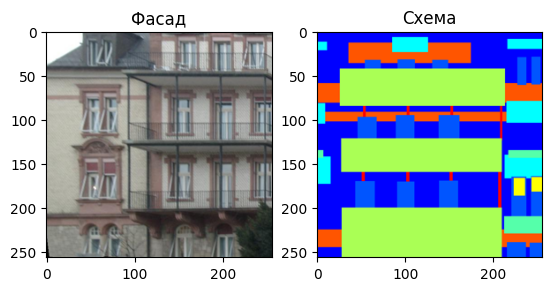

In [20]:
batch = next(iter(train_dataloader))
print("Фасады:", batch['facade'].shape)  
print("Схемы:", batch['scheme'].shape)   

# визуализация
def show_images(facade, scheme):
    
    facade = facade * 0.5 + 0.5
    scheme = scheme * 0.5 + 0.5

    fig, ax = plt.subplots(1, 2)
    ax[0].imshow(facade.permute(1, 2, 0))
    ax[0].set_title("Фасад")
    ax[1].imshow(scheme.permute(1, 2, 0))
    ax[1].set_title("Схема")
    plt.show()

show_images(batch['facade'][0], batch['scheme'][0])

In [21]:
def sample_images(batches_done):
    batch = next(iter(val_dataloader))
    G_AB.eval()
    G_BA.eval()
    real_facade = Variable(batch["facade"].type(Tensor))  # Реальные фасады
    real_scheme = Variable(batch["scheme"].type(Tensor))  # Реальные схемы
    with torch.no_grad():
        fake_scheme = G_AB(real_facade)  # Генерируем схемы из фасадов
        fake_facade = G_BA(real_scheme)  # Генерируем фасады из схем
    real_facade_grid = make_grid(real_facade, nrow=5, normalize=True)
    fake_scheme_grid = make_grid(fake_scheme, nrow=5, normalize=True)
    real_scheme_grid = make_grid(real_scheme, nrow=5, normalize=True)
    fake_facade_grid = make_grid(fake_facade, nrow=5, normalize=True)
    image_grid = torch.cat((real_facade_grid, fake_scheme_grid,
                          real_scheme_grid, fake_facade_grid), 1)

    
    save_dir = f"C:/dataset/facade/cyclegan_images/{opt.dataset_name}"
    os.makedirs(save_dir, exist_ok=True)
    save_image(image_grid,
              os.path.join(save_dir, f"{batches_done}.png"),
              normalize=False)

    
    G_AB.train()
    G_BA.train()

In [31]:
fake_facade_buffer = ReplayBuffer()
fake_scheme_buffer = ReplayBuffer()


prev_time = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler = torch.cuda.amp.GradScaler()

G_AB.to(device)
G_BA.to(device)
D_A.to(device)
D_B.to(device)

for epoch in range(opt.epoch, opt.n_epochs):
    for i, batch in enumerate(train_dataloader):

        real_facade = batch["facade"].to(device)
        real_scheme = batch["scheme"].to(device)
        valid = torch.ones((real_facade.size(0), *D_A.output_shape), device=device)
        fake = torch.zeros((real_facade.size(0), *D_A.output_shape), device=device)

        G_AB.train()
        G_BA.train()
        optimizer_G.zero_grad()
        

        
        loss_id_facade = criterion_identity(G_BA(real_facade), real_facade)
        loss_id_scheme = criterion_identity(G_AB(real_scheme), real_scheme)
        loss_identity = (loss_id_facade + loss_id_scheme) / 2

        
        fake_scheme = G_AB(real_facade)
        loss_GAN_AB = criterion_GAN(D_B(fake_scheme), valid)

        fake_facade = G_BA(real_scheme)
        loss_GAN_BA = criterion_GAN(D_A(fake_facade), valid)
        loss_GAN = (loss_GAN_AB + loss_GAN_BA) / 2

        
        recov_facade = G_BA(fake_scheme)
        loss_cycle_A = criterion_cycle(recov_facade, real_facade)

        recov_scheme = G_AB(fake_facade)
        loss_cycle_B = criterion_cycle(recov_scheme, real_scheme)
        loss_cycle = (loss_cycle_A + loss_cycle_B) / 2

        
        loss_G = loss_GAN + opt.lambda_cyc * loss_cycle + opt.lambda_id * loss_identity
        loss_G.backward()
        optimizer_G.step()


        optimizer_D_A.zero_grad()


        loss_real = criterion_GAN(D_A(real_facade), valid)
        fake_facade_ = fake_facade_buffer.push_and_pop(fake_facade)
        loss_fake = criterion_GAN(D_A(fake_facade_.detach()), fake)

        loss_D_A = (loss_real + loss_fake) / 2
        loss_D_A.backward()
        optimizer_D_A.step()

        optimizer_D_B.zero_grad()

        loss_real = criterion_GAN(D_B(real_scheme), valid)
        fake_scheme_ = fake_scheme_buffer.push_and_pop(fake_scheme)
        loss_fake = criterion_GAN(D_B(fake_scheme_.detach()), fake)

        loss_D_B = (loss_real + loss_fake) / 2
        loss_D_B.backward()
        optimizer_D_B.step()


        loss_D = (loss_D_A + loss_D_B) / 2


        batches_done = epoch * len(train_dataloader) + i
        batches_left = opt.n_epochs * len(train_dataloader) - batches_done
        time_left = datetime.timedelta(seconds=int(batches_left * (time.time() - prev_time)))
        prev_time = time.time()

        sys.stdout.write(
            f"\r[Epoch {epoch}/{opt.n_epochs}] [Batch {i}/{len(train_dataloader)}] "
            f"[D loss: {loss_D.item():.4f}] "
            f"[G loss: {loss_G.item():.4f}, adv: {loss_GAN.item():.4f}, "
            f"cycle: {loss_cycle.item():.4f}, identity: {loss_identity.item():.4f}] "
            f"ETA: {time_left}"
        )
        sys.stdout.flush()


        if batches_done % opt.sample_interval == 0:
            sample_images(batches_done)

    lr_scheduler_G.step()
    lr_scheduler_D_A.step()
    lr_scheduler_D_B.step()

    
    if opt.checkpoint_interval != -1 and epoch % opt.checkpoint_interval == 0:
        torch.save(G_AB.state_dict(), f"C:/dataset/cyclegan_models/{opt.dataset_name}/G_AB_{epoch}.pth")
        torch.save(G_BA.state_dict(), f"C:/dataset/cyclegan_models/{opt.dataset_name}/G_BA_{epoch}.pth")
        torch.save(D_A.state_dict(), f"C:/dataset/cyclegan_models/{opt.dataset_name}/D_A_{epoch}.pth")
        torch.save(D_B.state_dict(), f"C:/dataset/cyclegan_models/{opt.dataset_name}/D_B_{epoch}.pth")

C:\Users\User\AppData\Local\Temp\ipykernel_9288\3584398528.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


[Epoch 9/10] [Batch 377/378] [D loss: 0.0737] [G loss: 2.7984, adv: 0.6158, cycle: 0.1602, identity: 0.1162] ETA: 0:00:00

Последние сгенерированные изображения:


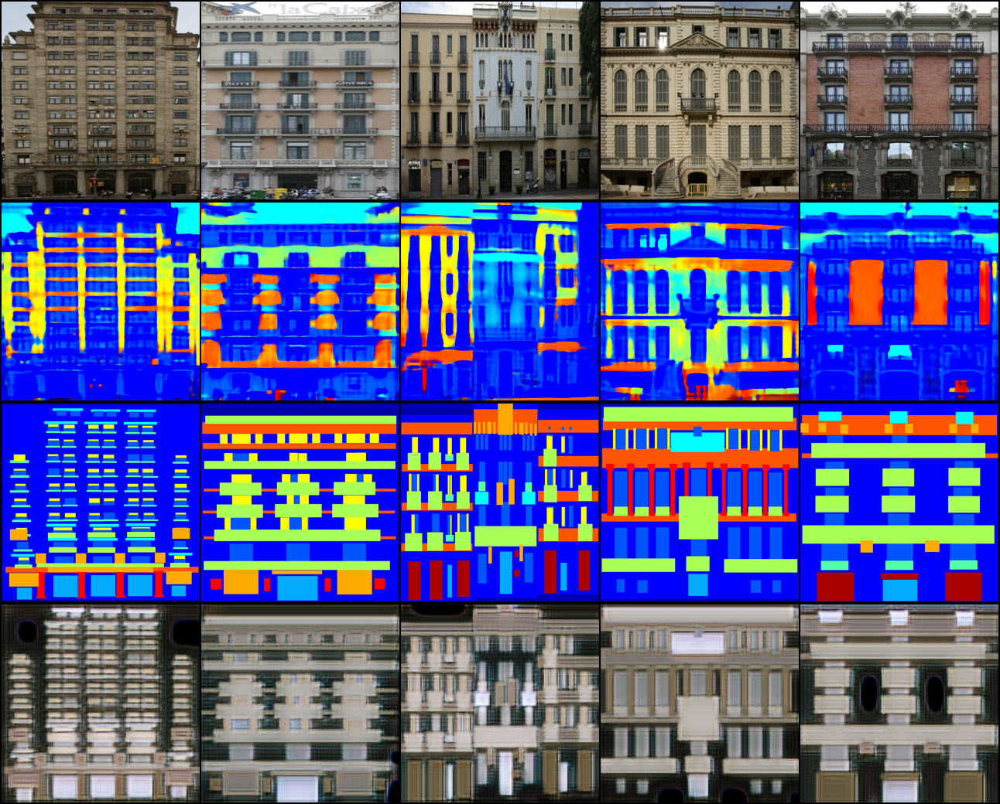

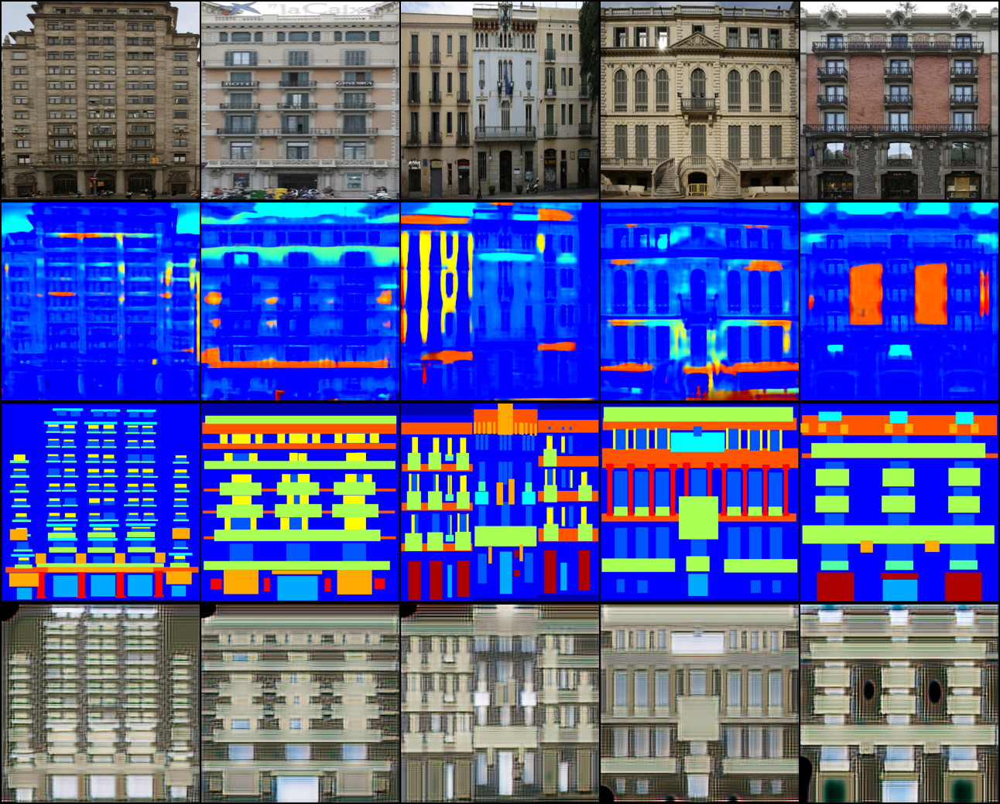

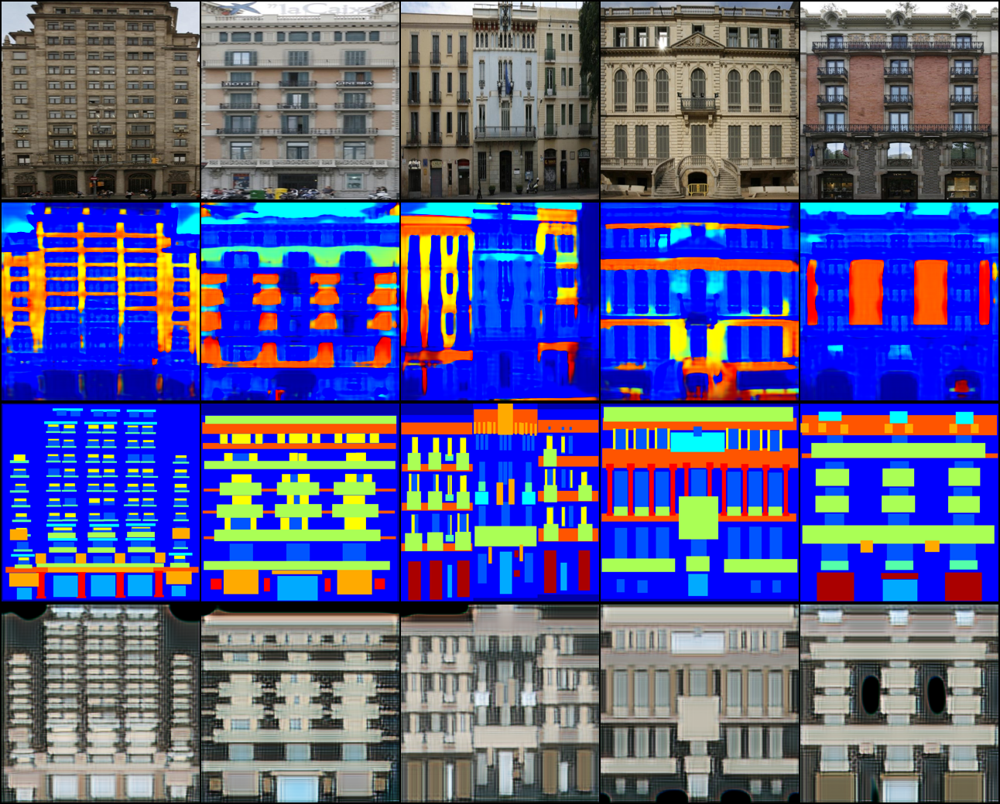

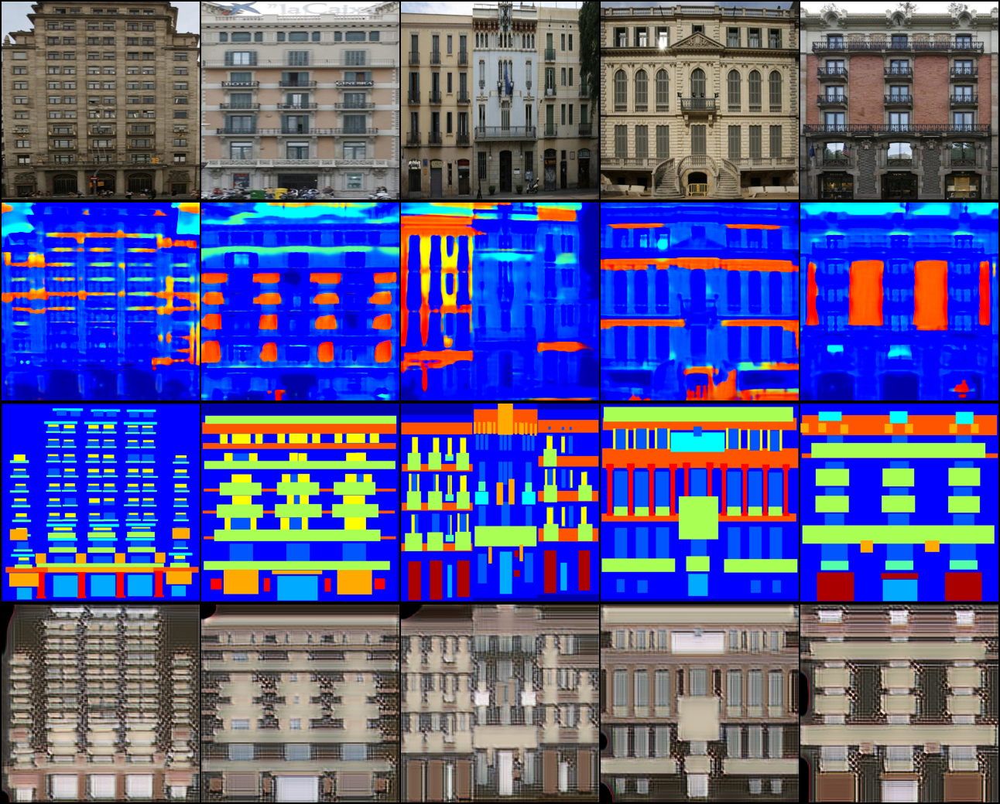

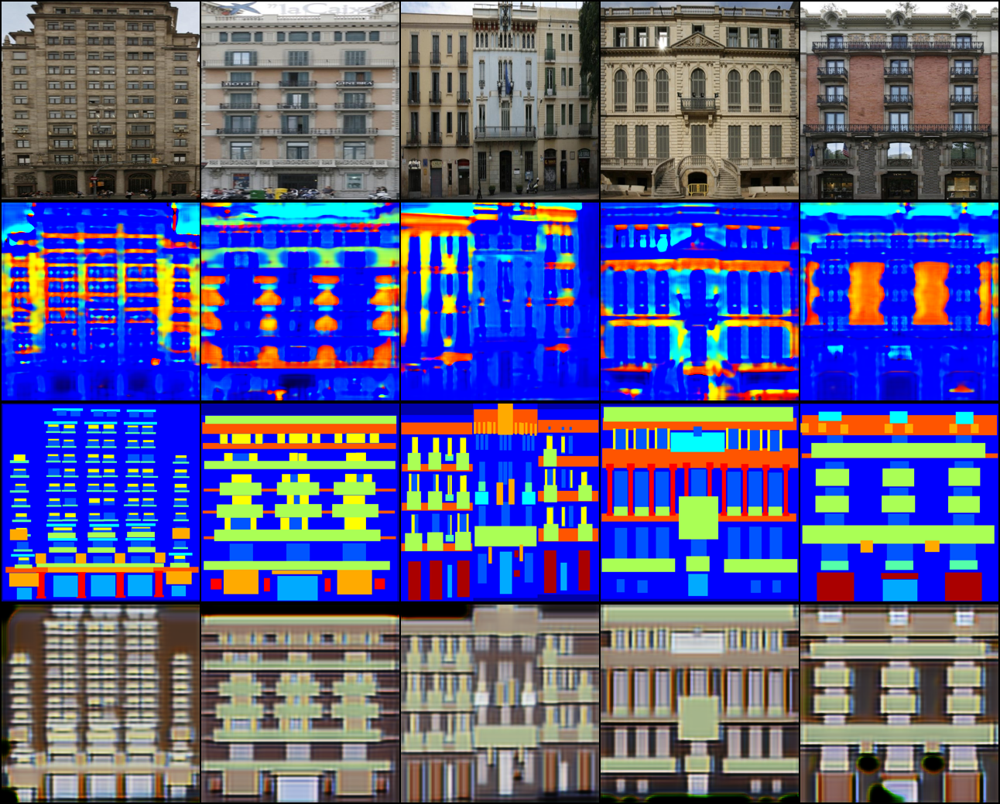

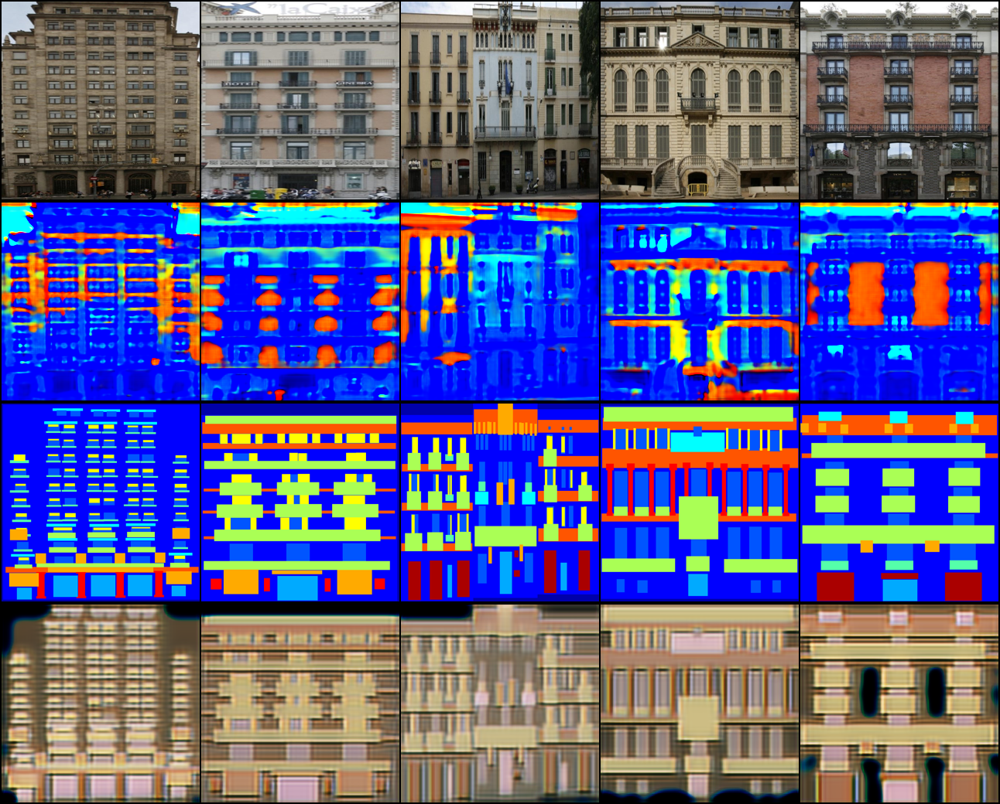

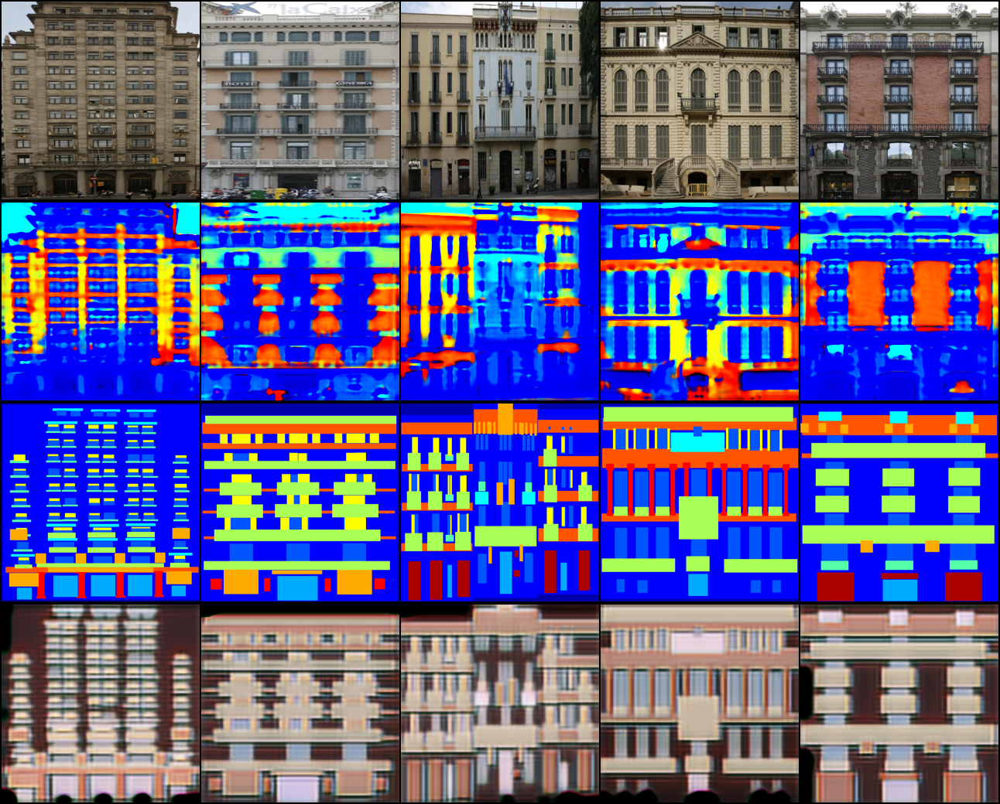

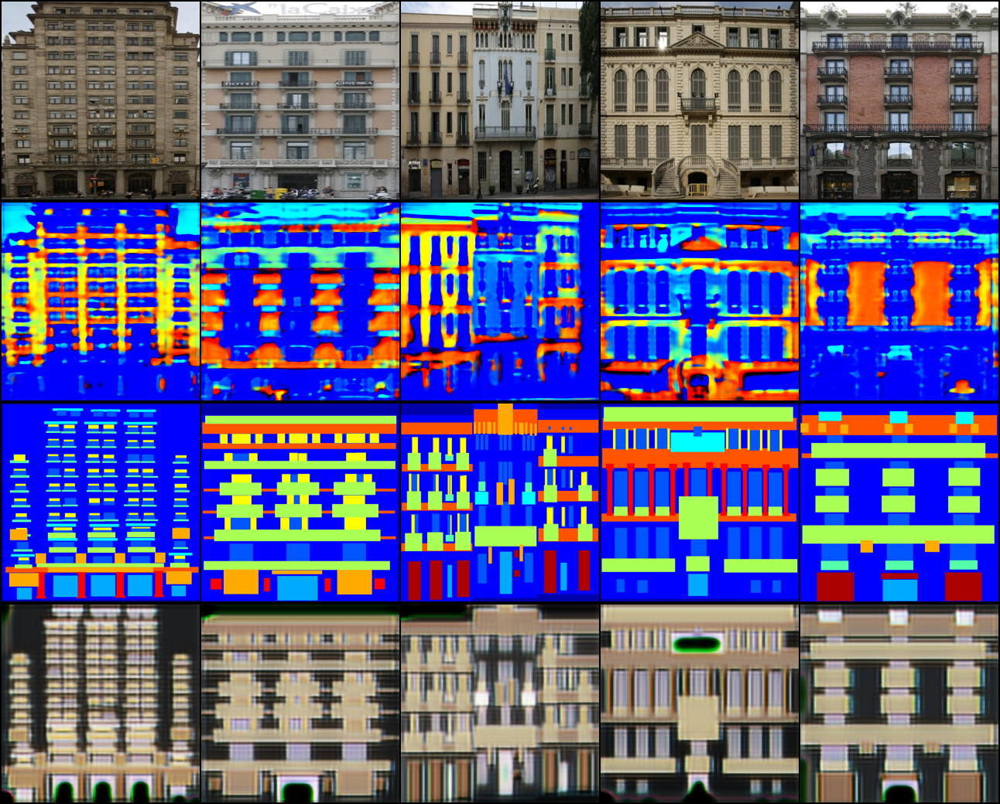

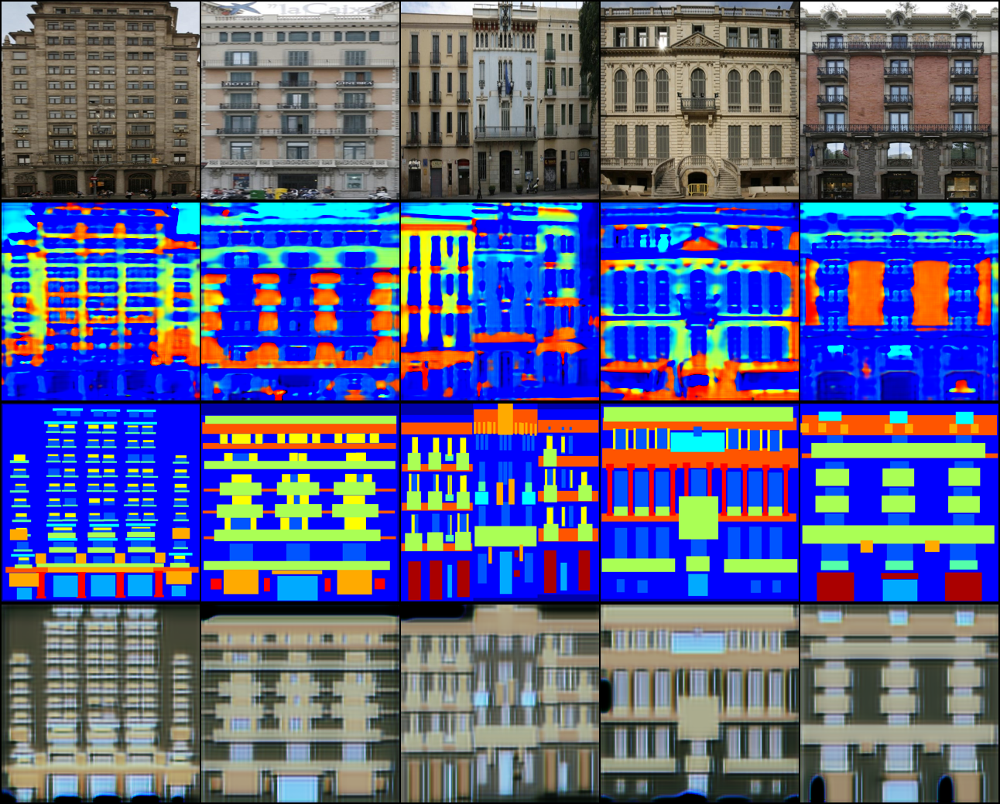

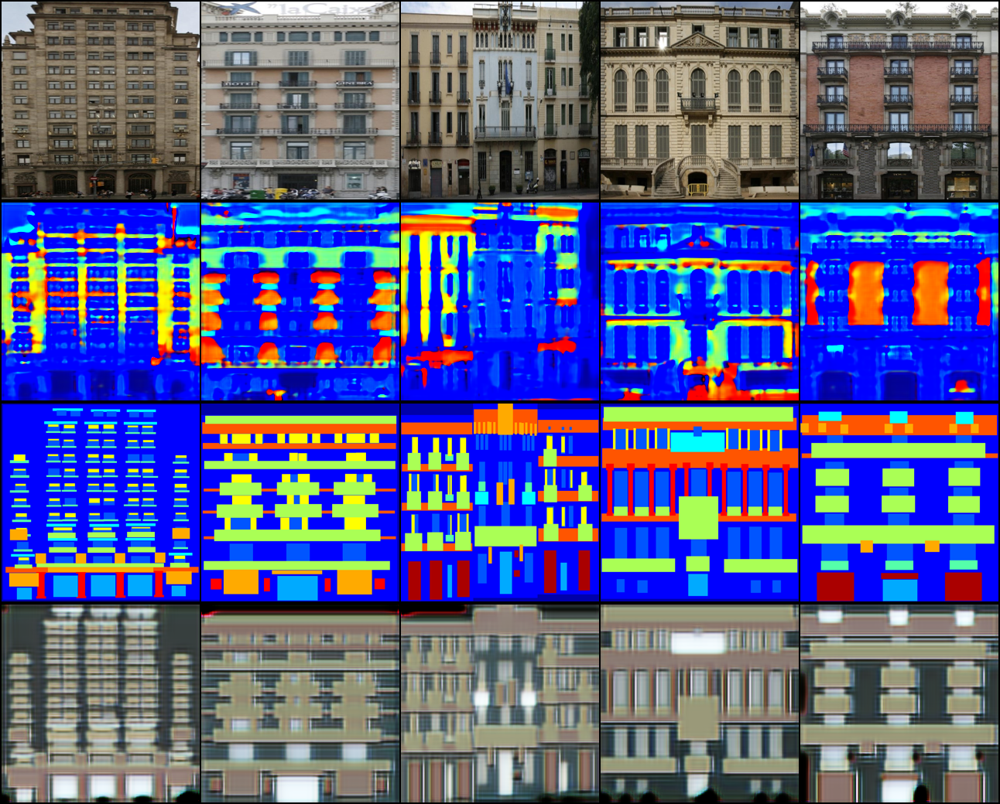

In [32]:
from IPython.display import Image, display
import glob
import os

image_files = sorted(glob.glob(f"C:/dataset/facade/cyclegan_images/{opt.dataset_name}/*.png"))

if image_files:
    print("Последние сгенерированные изображения:")
    for img_path in image_files[-10:]:
        display(Image(filename=img_path))
else:
    print("Изображения не найдены в папке.")